# E-Commerce Recommendation System
Implements EDA, Regression, Classification, Clustering.

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,f1_score,silhouette_score
df=pd.read_csv('ecommerce_dataset.csv')
reg_features=['Price','Browsing_Time','Previous_Purchases','Discount_Applied','Age','Category','Total_Spending']
X=df[reg_features]; y=df['Rating']
num=['Price','Browsing_Time','Previous_Purchases','Discount_Applied','Age','Total_Spending']; cat=['Category']
pre=ColumnTransformer([('num',StandardScaler(),num),('cat',OneHotEncoder(handle_unknown='ignore'),cat)])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
pipe=Pipeline([('pre',pre),('model',Ridge())])
gs=GridSearchCV(pipe,{'model__alpha':[0.1,1,10]},cv=3)
gs.fit(Xtr,ytr)
print('R2',r2_score(yte,gs.predict(Xte)))
# Classification
clfX=df[['Browsing_Time','Cart_Addition','Previous_Purchases','Rating','Price','Discount_Applied','Total_Spending']]
Xtr,Xte,ytr,yte=train_test_split(clfX,df['Purchase_Status'],test_size=0.2,random_state=42)
sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)
clf=GridSearchCV(LogisticRegression(),{'C':[0.1,1,10],'max_iter':[500]},cv=3)
clf.fit(Xtr,ytr)
print('Accuracy',accuracy_score(yte,clf.predict(Xte)))
# Clustering
kmdata=df[['Browsing_Time','Previous_Purchases','Total_Spending']]
km=KMeans(n_clusters=4,random_state=42,n_init=10).fit(kmdata)
print('Silhouette',silhouette_score(kmdata,km.labels_))


R2 0.37133508876857
Accuracy 0.734
Silhouette 0.563279456806096


# E-Commerce Recommendation System

## Implementing and Comparing Machine Learning Algorithms for an E-Commerce Recommendation System

**Student Name:** K Abhiram

**Student ID:**  G40 AIML


## Objective

The objective of this project is to build an e-commerce recommendation system using machine learning.

The project includes:

- Predicting product ratings using Regression
- Predicting purchase likelihood using Logistic Regression
- Segmenting customers using K-Means Clustering
- Hyperparameter tuning using GridSearchCV
- Comparing model performance

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    silhouette_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [40]:
df = pd.read_csv("ecommerce_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [41]:
df.head()

,User_ID,Product_ID,Category,Price,Browsing_Time,Previous_Purchases,Cart_Addition,Age,Gender,Location,Discount_Applied,Total_Spending,Rating,Purchase_Status
0,U00000,P0054,Electronics,116.89,21.9,6,1,60,Female,North,1,1768.27,5.0,1
1,U00001,P0464,Electronics,334.83,21.6,10,0,52,Female,West,0,2134.03,5.0,0
2,U00002,P0393,Home,385.76,6.9,25,1,27,Female,East,1,4924.26,5.0,1
3,U00003,P0263,Home,91.65,2.1,3,1,64,Male,West,0,466.76,3.5,0
4,U00004,P0260,Home,31.49,9.8,3,0,64,Male,South,1,602.67,3.9,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             5000 non-null   object 
 1   Product_ID          5000 non-null   object 
 2   Category            5000 non-null   object 
 3   Price               5000 non-null   float64
 4   Browsing_Time       5000 non-null   float64
 5   Previous_Purchases  5000 non-null   int64  
 6   Cart_Addition       5000 non-null   int64  
 7   Age                 5000 non-null   int64  
 8   Gender              5000 non-null   object 
 9   Location            5000 non-null   object 
 10  Discount_Applied    5000 non-null   int64  
 11  Total_Spending      5000 non-null   float64
 12  Rating              5000 non-null   float64
 13  Purchase_Status     5000 non-null   int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 547.0+ KB


In [43]:
df.describe()

,Price,Browsing_Time,Previous_Purchases,Cart_Addition,Age,Discount_Applied,Total_Spending,Rating,Purchase_Status
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,254.329104,15.546920,14.623200,0.496400,41.357400,0.499200,2506.262750,4.749400,0.651600
std,141.088382,8.304692,8.744399,0.500037,13.738596,0.500049,1426.250815,0.588742,0.476511
min,10.150000,1.000000,0.000000,0.000000,18.000000,0.000000,50.710000,1.600000,0.000000
25%,131.817500,8.200000,7.000000,0.000000,29.000000,0.000000,1238.185000,5.000000,0.000000
50%,257.425000,15.650000,15.000000,0.000000,42.000000,0.000000,2520.015000,5.000000,1.000000
75%,373.732500,22.700000,22.000000,1.000000,54.000000,1.000000,3718.970000,5.000000,1.000000
max,499.990000,30.000000,29.000000,1.000000,64.000000,1.000000,4998.900000,5.000000,1.000000


In [44]:
df.isnull().sum()

User_ID               0
Product_ID            0
Category              0
Price                 0
Browsing_Time         0
Previous_Purchases    0
Cart_Addition         0
Age                   0
Gender                0
Location              0
Discount_Applied      0
Total_Spending        0
Rating                0
Purchase_Status       0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

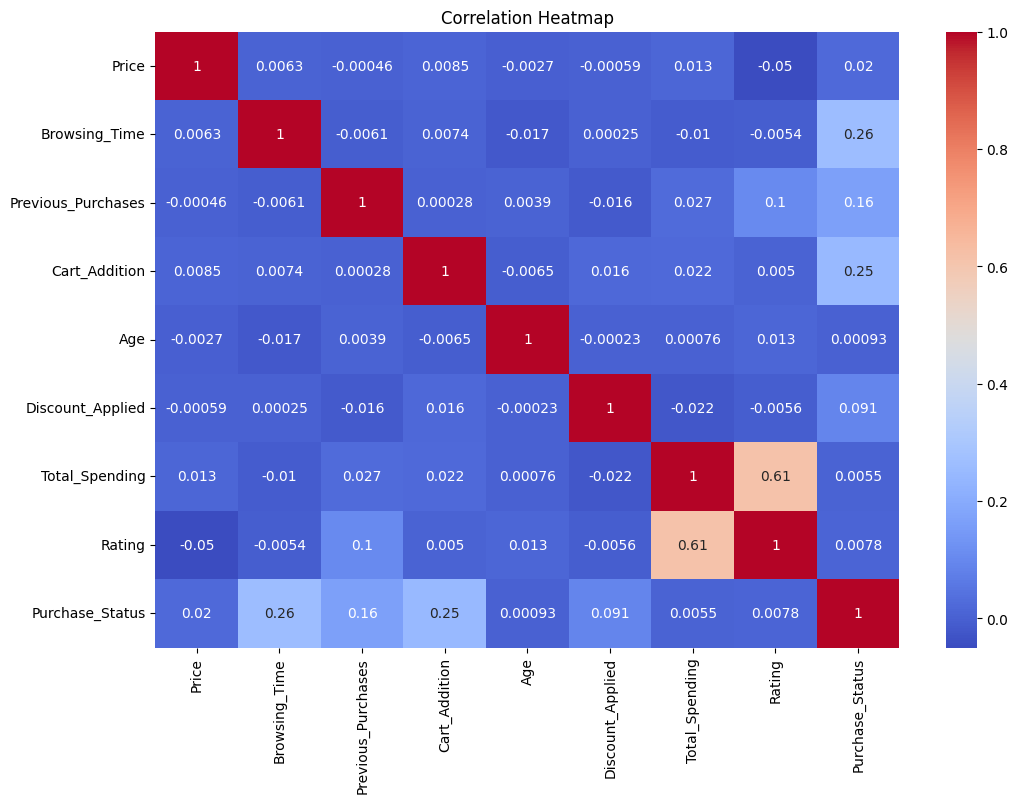

In [46]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

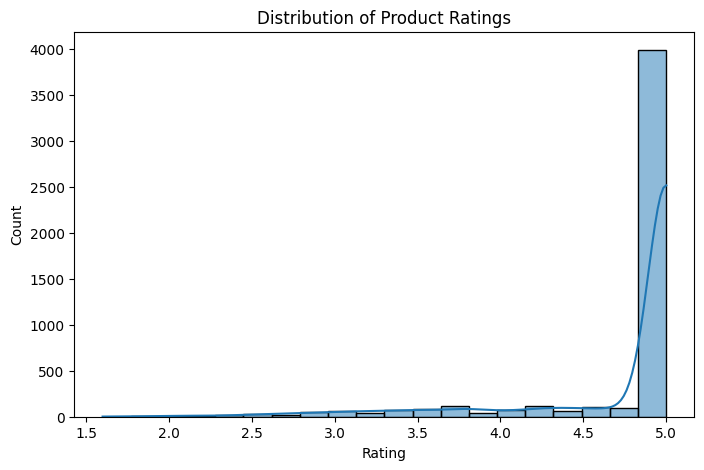

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=20, kde=True)

plt.title("Distribution of Product Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

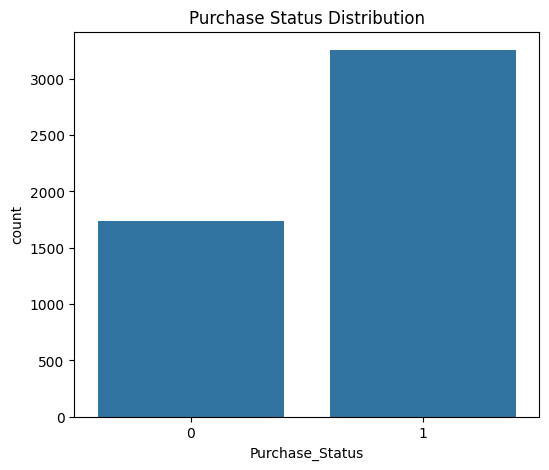

In [48]:
plt.figure(figsize=(6,5))

sns.countplot(x="Purchase_Status", data=df)

plt.title("Purchase Status Distribution")

plt.show()

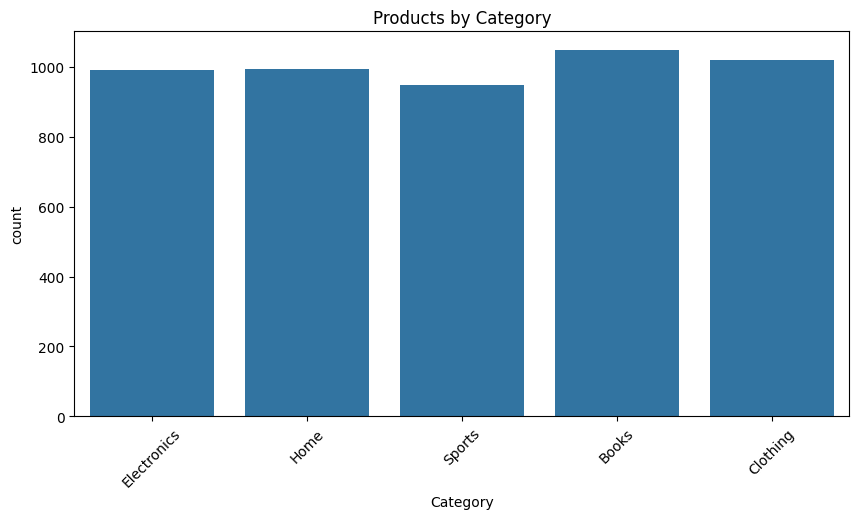

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(x="Category", data=df)

plt.xticks(rotation=45)

plt.title("Products by Category")

plt.show()

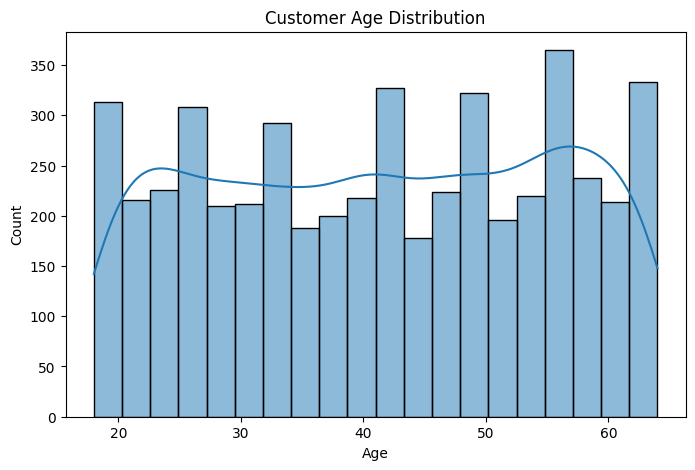

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")

plt.show()

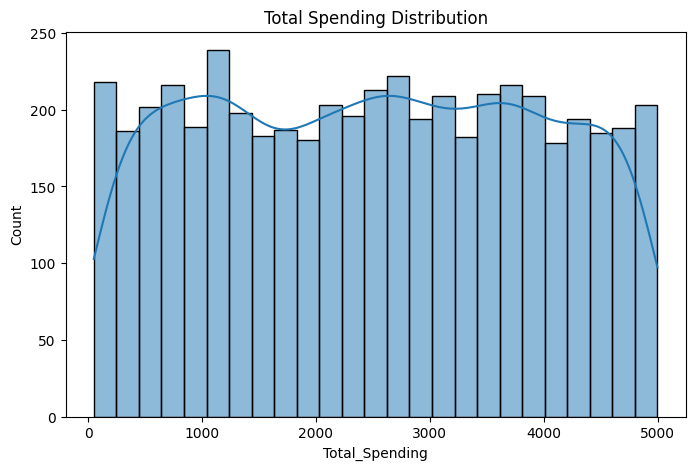

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Spending"], bins=25, kde=True)

plt.title("Total Spending Distribution")

plt.show()

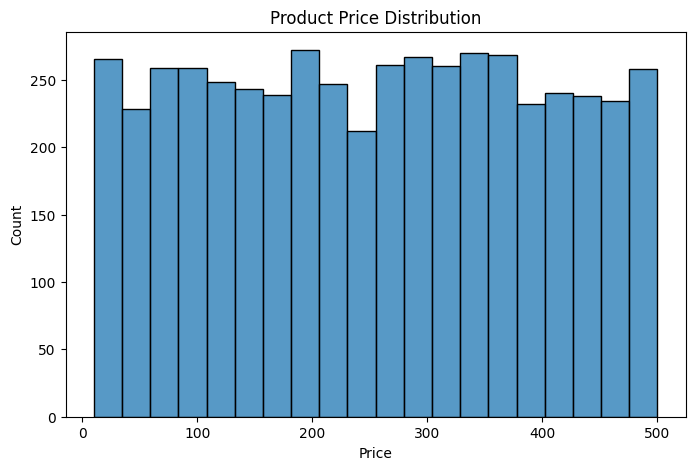

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=20)

plt.title("Product Price Distribution")

plt.show()

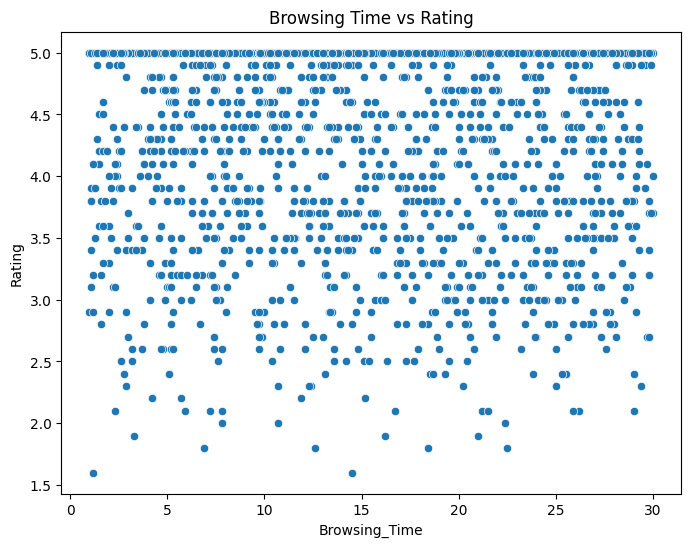

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Browsing_Time",
    y="Rating",
    data=df
)

plt.title("Browsing Time vs Rating")

plt.show()

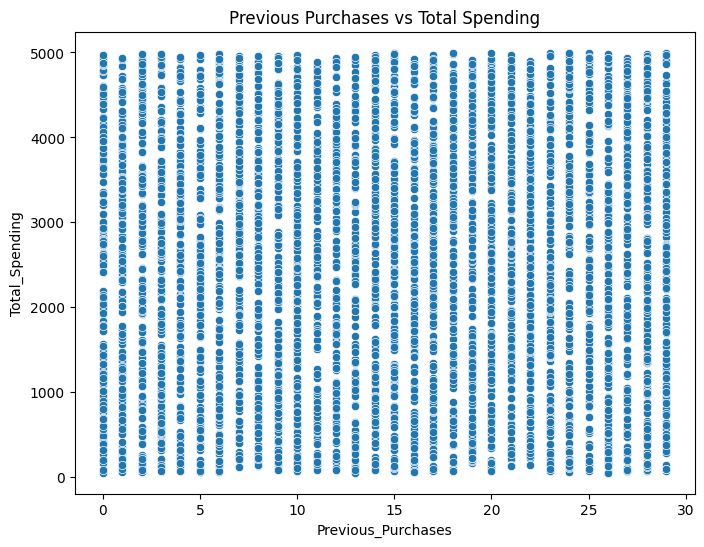

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Previous_Purchases",
    y="Total_Spending",
    data=df
)

plt.title("Previous Purchases vs Total Spending")

plt.show()

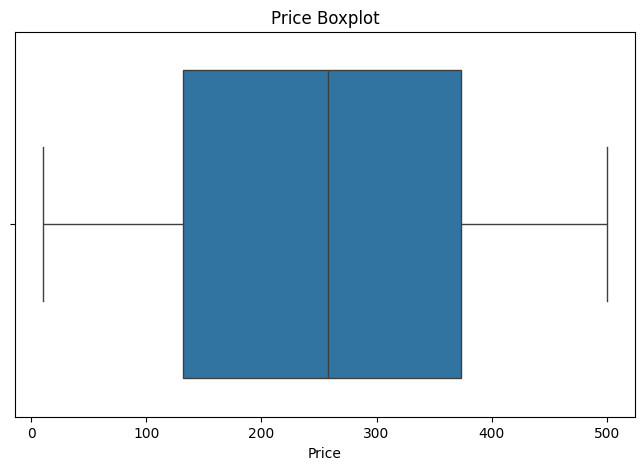

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Price Boxplot")

plt.show()

## Part A: Regression – Rating Prediction

In this section, we build regression models to predict customer ratings using:
- Linear Regression
- Ridge Regression

The performance is evaluated using:
- MAE
- MSE
- RMSE
- R² Score

In [56]:
# ==========================
# Part A - Regression
# ==========================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and Target
X = df[['Price',
        'Browsing_Time',
        'Previous_Purchases',
        'Discount_Applied',
        'Age',
        'Category',
        'Total_Spending']]

y = df['Rating']

# Numerical and Categorical columns
num_cols = [
    'Price',
    'Browsing_Time',
    'Previous_Purchases',
    'Discount_Applied',
    'Age',
    'Total_Spending'
]

cat_cols = ['Category']

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
# Linear Regression

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_predictions = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae,3))
print("MSE :", round(linear_mse,3))
print("RMSE:", round(linear_rmse,3))
print("R² :", round(linear_r2,3))

Linear Regression Results
-------------------------
MAE : 0.345
MSE : 0.219
RMSE: 0.468
R² : 0.371


In [58]:
# Ridge Regression with GridSearchCV

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

parameters = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    parameters,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

ridge_predictions = grid.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Best Alpha:", grid.best_params_['model__alpha'])

print("\nRidge Regression Results")
print("------------------------")
print("MAE :", round(ridge_mae,3))
print("MSE :", round(ridge_mse,3))
print("RMSE:", round(ridge_rmse,3))
print("R² :", round(ridge_r2,3))

Best Alpha: 100

Ridge Regression Results
------------------------
MAE : 0.341
MSE : 0.219
RMSE: 0.468
R² : 0.372


In [59]:
# Comparison Table

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [linear_mae, ridge_mae],
    "RMSE": [linear_rmse, ridge_rmse],
    "R2 Score": [linear_r2, ridge_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.344756,0.468059,0.371268
1,Ridge Regression,0.341432,0.467900,0.371696


## Part B: Classification – Purchase Likelihood Prediction

In this section, we build a Logistic Regression model to predict whether a customer will purchase a product.

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

In [60]:
# ==========================
# Part B - Classification
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

X = df[
    [
        'Browsing_Time',
        'Cart_Addition',
        'Previous_Purchases',
        'Rating',
        'Price',
        'Discount_Applied',
        'Total_Spending'
    ]
]

y = df['Purchase_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
# Logistic Regression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:,1]

In [62]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
roc = roc_auc_score(y_test, probabilities)

print("Accuracy :", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall   :", round(recall,3))
print("F1 Score :", round(f1,3))
print("ROC AUC  :", round(roc,3))

Accuracy : 0.734
Precision: 0.754
Recall   : 0.881
F1 Score : 0.812
ROC AUC  : 0.77


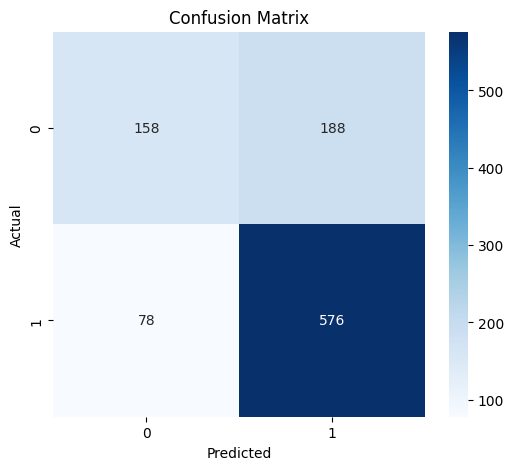

In [63]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [64]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.67      0.46      0.54       346
           1       0.75      0.88      0.81       654

    accuracy                           0.73      1000
   macro avg       0.71      0.67      0.68      1000
weighted avg       0.72      0.73      0.72      1000



## Part C: Customer Segmentation using K-Means Clustering

Customer segmentation groups users with similar shopping behaviour.

We use:

- K-Means Clustering
- Elbow Method
- Silhouette Score

This helps identify:

- High-value customers
- Frequent buyers
- Discount-sensitive customers
- Browsers with low purchases

In [65]:
# Features for clustering

cluster_data = df[
    [
        "Browsing_Time",
        "Previous_Purchases",
        "Total_Spending"
    ]
]

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

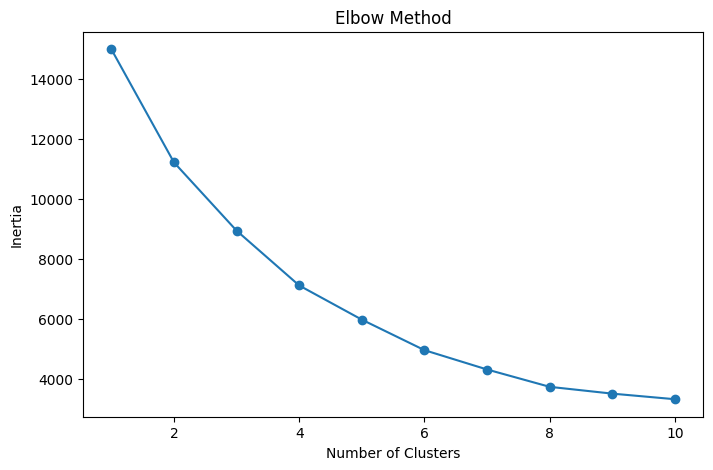

In [66]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K,inertia,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [67]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

df["Cluster"] = clusters

In [68]:
score = silhouette_score(
    cluster_scaled,
    clusters
)

print("Silhouette Score:",round(score,3))

Silhouette Score: 0.265


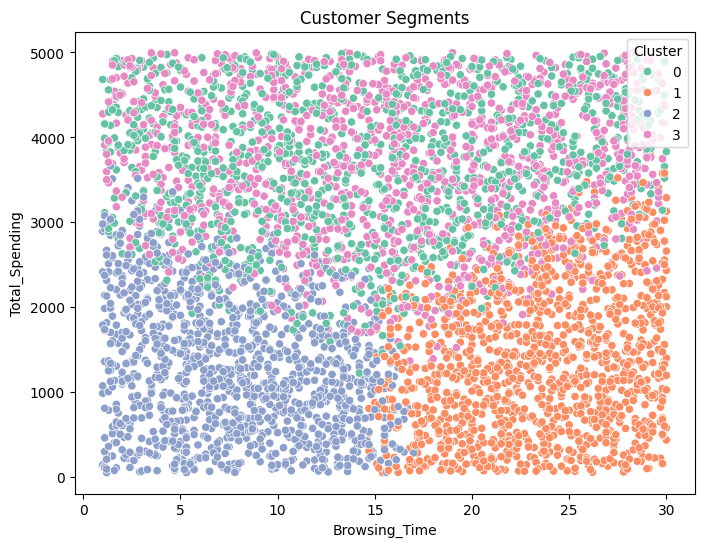

In [69]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Browsing_Time"],
    y=df["Total_Spending"],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [70]:
df.groupby("Cluster")[
    [
        "Browsing_Time",
        "Previous_Purchases",
        "Total_Spending"
    ]
].mean()

,Browsing_Time,Previous_Purchases,Total_Spending
Cluster,,,
0,14.577910,6.171623,3670.462617
1,23.482952,13.494081,1368.760947
2,7.776447,15.048085,1300.666675
3,16.013394,22.792325,3672.717171


# Part D: Hyperparameter Tuning

Hyperparameter tuning helps improve model performance by selecting the best parameters.

Techniques used:
- GridSearchCV
- Ridge Regression (alpha)
- Logistic Regression (C)

In [71]:
# Best Ridge Parameter

print("Best Ridge Alpha:", grid.best_params_)

Best Ridge Alpha: {'model__alpha': 100}


In [72]:
# Logistic Regression Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

parameters = {
    "C":[0.01,0.1,1,10,100]
}

grid_logistic = GridSearchCV(
    LogisticRegression(max_iter=500),
    parameters,
    cv=5
)

grid_logistic.fit(X_train,y_train)

print("Best Parameters")

print(grid_logistic.best_params_)

Best Parameters
{'C': 1}


# Part E: Final Model Comparison

In [73]:
comparison = pd.DataFrame({

    "Task":[
        "Regression",
        "Classification",
        "Clustering"
    ],

    "Model":[
        "Ridge Regression",
        "Logistic Regression",
        "K-Means"
    ],

    "Main Metric":[
        round(ridge_r2,3),
        round(accuracy,3),
        round(score,3)
    ]

})

comparison

,Task,Model,Main Metric
0,Regression,Ridge Regression,0.372
1,Classification,Logistic Regression,0.734
2,Clustering,K-Means,0.265


# Business Interpretation

### Regression
The regression model predicts customer ratings, helping recommend products users are likely to rate highly.

### Classification
The logistic regression model predicts purchase likelihood, enabling targeted marketing and personalized promotions.

### Clustering
K-Means groups customers into meaningful segments, allowing businesses to tailor recommendations and loyalty programs.

Overall, combining these approaches supports a more effective recommendation system.

# Conclusion

This project successfully implemented and compared three machine learning techniques:

- Linear and Ridge Regression for rating prediction
- Logistic Regression for purchase prediction
- K-Means Clustering for customer segmentation

The results demonstrate how these models can improve recommendation quality, customer targeting, and business decision-making.

Future work could include advanced recommendation techniques such as collaborative filtering, matrix factorization, or deep learning models.